# Accelerator oscillation curves with `nuosclab`

This notebook reproduces **accelerator-style three-flavor PMNS oscillation curves** for long-baseline experiments.

The main channels are:

- $P(\nu_\mu \rightarrow \nu_e)$: appearance
- $P(\nu_\mu \rightarrow \nu_\mu)$: disappearance

We will plot these channels for **NOvA**, **DUNE**, and **T2K**, then do a small accelerator sensitivity study by varying $\delta_{CP}$.


## 1. Setup

This notebook avoids the interactive `widget` backend because it can cause backend errors in VS Code/Jupyter. It uses normal static Matplotlib plots.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace

from nuosclab import ExplorerConfig, PMNSParams, compute_curves

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 2. Helper functions

The probability array uses flavor indices:

- $e = 0$
- $\mu = 1$
- $\tau = 2$

So:

- $P(\nu_\mu \rightarrow \nu_e)$ means initial flavor $\mu$, final flavor $e$
- $P(\nu_\mu \rightarrow \nu_\mu)$ means initial flavor $\mu$, final flavor $\mu$


In [7]:
flavor = {
    "e": 0,
    "mu": 1,
    "tau": 2,
}

def channel_probability(curves, initial="mu", final="e"):
    """
    Return P(nu_initial -> nu_final).

    nuosclab convention:
    P[n, beta, alpha] = P(nu_alpha -> nu_beta)
    where alpha is the initial flavor and beta is the final flavor.
    """
    alpha = flavor[initial]
    beta = flavor[final]
    return curves.live[:, beta, alpha]


def compute_accelerator_curves(experiment, antineutrino=False, pmns=None, n_points=800):
    """Compute accelerator oscillation curves for one experiment preset."""
    if pmns is None:
        pmns = PMNSParams()
        
    config = ExplorerConfig(
        experiment=experiment,
        pmns=pmns,
        antineutrino=antineutrino,
        n_points=n_points,
        include_standard=True,
        include_nominal=True,
    )
    return compute_curves(config)


## 3. Standard accelerator curves: NOvA, DUNE, and T2K

These are the canonical accelerator-style curves. The two most important channels are:

- $P(\nu_\mu \rightarrow \nu_e)$ appearance
- $P(\nu_\mu \rightarrow \nu_\mu)$ disappearance

The vertical dotted line marks the approximate experiment beam-energy peak from the `nuosclab` preset.


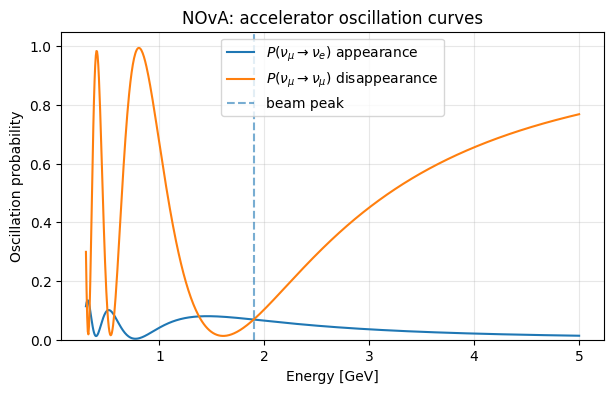

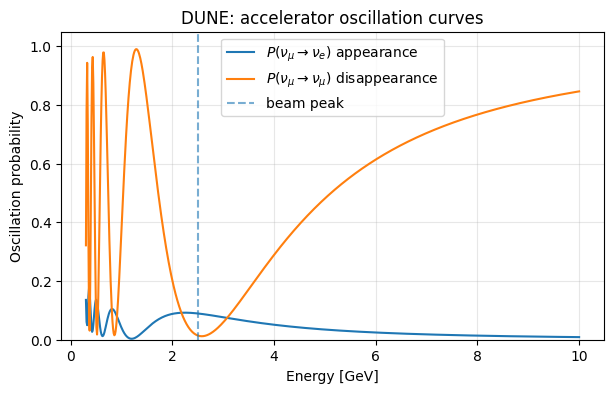

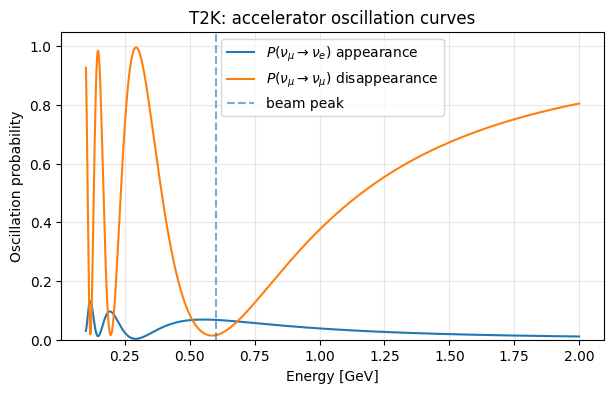

In [8]:
experiments = ["NOvA", "DUNE", "T2K"]

for experiment in experiments:
    curves = compute_accelerator_curves(experiment, antineutrino=False)
    E = curves.energy_gev
    
    P_mue = channel_probability(curves, initial="mu", final="e")
    P_mumu = channel_probability(curves, initial="mu", final="mu")
    
    plt.figure()
    plt.plot(E, P_mue, label=r"$P(\nu_\mu \rightarrow \nu_e)$ appearance")
    plt.plot(E, P_mumu, label=r"$P(\nu_\mu \rightarrow \nu_\mu)$ disappearance")
    plt.axvline(curves.preset.E_peak, linestyle="--", alpha=0.6, label="beam peak")
    
    plt.xlabel("Energy [GeV]")
    plt.ylabel("Oscillation probability")
    plt.title(f"{experiment}: accelerator oscillation curves")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.show()


### Observation

The $\nu_\mu \rightarrow \nu_\mu$ curve is a **survival probability**. When it dips, many original muon neutrinos have oscillated into other flavors.

The $\nu_\mu \rightarrow \nu_e$ curve is an **appearance probability**. It is usually smaller because only some of the original muon neutrino beam appears as electron neutrinos at the far detector.


## 4. Neutrino vs antineutrino accelerator curves

For accelerator experiments, it is also useful to compare neutrino mode and antineutrino mode:

- $P(\nu_\mu \rightarrow \nu_e)$
- $P(\bar{\nu}_\mu \rightarrow \bar{\nu}_e)$

This comparison is related to $\delta_{CP}$ and matter effects.


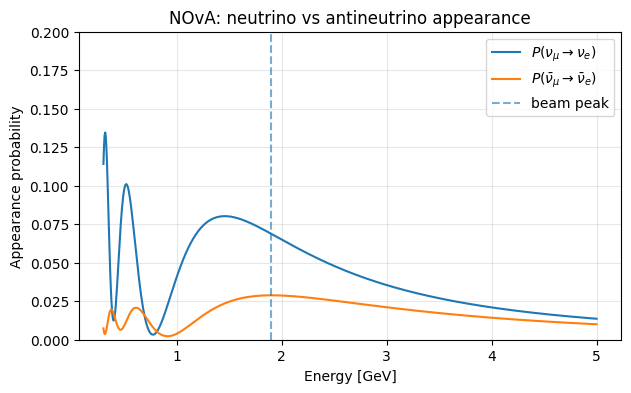

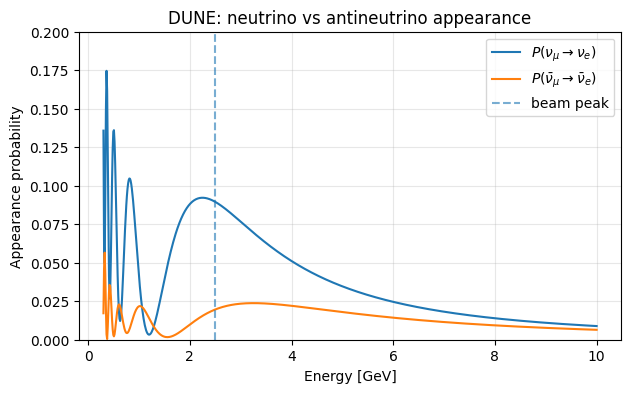

In [9]:
for experiment in ["NOvA", "DUNE"]:
    nu_curves = compute_accelerator_curves(experiment, antineutrino=False)
    antinu_curves = compute_accelerator_curves(experiment, antineutrino=True)
    
    E = nu_curves.energy_gev
    P_nu = channel_probability(nu_curves, initial="mu", final="e")
    P_antinu = channel_probability(antinu_curves, initial="mu", final="e")
    
    plt.figure()
    plt.plot(E, P_nu, label=r"$P(\nu_\mu \rightarrow \nu_e)$")
    plt.plot(E, P_antinu, label=r"$P(\bar{\nu}_\mu \rightarrow \bar{\nu}_e)$")
    plt.axvline(nu_curves.preset.E_peak, linestyle="--", alpha=0.6, label="beam peak")
    
    plt.xlabel("Energy [GeV]")
    plt.ylabel("Appearance probability")
    plt.title(f"{experiment}: neutrino vs antineutrino appearance")
    plt.ylim(0, 0.2)
    plt.legend()
    plt.show()


### Observation

The neutrino and antineutrino appearance curves do not have to match exactly. In long-baseline accelerator experiments, differences can come from both matter effects and the CP-violating phase $\delta_{CP}$.


## 5. $\delta_{CP}$ scan for accelerator appearance

Now we vary $\delta_{CP}$ and look at the accelerator appearance channel:

$$
P(\nu_\mu \rightarrow \nu_e)
$$

This is one of the main reasons accelerator experiments study electron-neutrino appearance.


<>:17: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:17: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/var/folders/55/vfnhjknn20qfb8vcq2r2c3ph0000gn/T/ipykernel_5004/2551293523.py:17: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  plt.title(f"{experiment}: $\delta_{{CP}}$ effect on accelerator appearance")


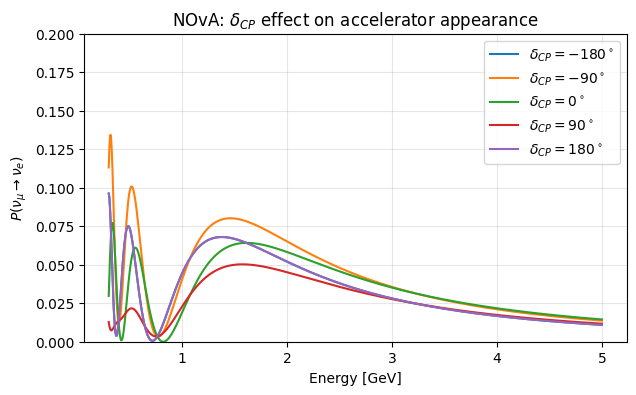

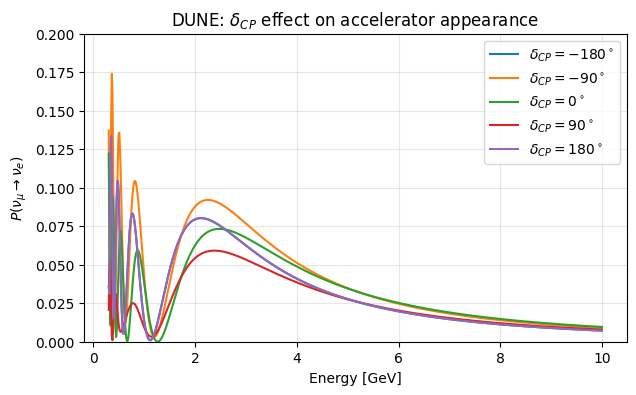

In [10]:
base_pmns = PMNSParams()
delta_cp_values_deg = [-180, -90, 0, 90, 180]

for experiment in ["NOvA", "DUNE"]:
    plt.figure()
    
    for delta_deg in delta_cp_values_deg:
        pmns = replace(base_pmns, delta_cp=np.radians(delta_deg))
        curves = compute_accelerator_curves(experiment, antineutrino=False, pmns=pmns)
        E = curves.energy_gev
        P_mue = channel_probability(curves, initial="mu", final="e")
        
        plt.plot(E, P_mue, label=rf"$\delta_{{CP}} = {delta_deg}^\circ$")
    
    plt.xlabel("Energy [GeV]")
    plt.ylabel(r"$P(\nu_\mu \rightarrow \nu_e)$")
    plt.title(f"{experiment}: $\delta_{{CP}}$ effect on accelerator appearance")
    plt.ylim(0, 0.2)
    plt.legend()
    plt.show()


### Observation

Changing $\delta_{CP}$ changes the size and shape of the $\nu_\mu \rightarrow \nu_e$ appearance probability. This is why accelerator experiments such as NOvA and DUNE are useful for studying CP violation in the neutrino sector.


## 6. Small conclusion

This notebook reproduces accelerator-style oscillation curves for NOvA, DUNE, and T2K. The key accelerator channels are:

- $P(\nu_\mu \rightarrow \nu_e)$ appearance
- $P(\nu_\mu \rightarrow \nu_\mu)$ disappearance

The appearance channel is especially important for studying $\delta_{CP}$, mass ordering, and matter effects in long-baseline experiments.
